In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

In [ ]:
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
ALPHA = 0.05

In [ ]:
def verdict(p, alpha=ALPHA):
    """Return a short verdict string for a given p-value."""
    return "REJECT H0" if p < alpha else "FAIL to reject H0"


def two_sample_z_test(a, b):
    """
    Two-sample z-test for the difference in means.
    H0: mu_a = mu_b
    z = (mean_a - mean_b) / sqrt(var_a/n_a + var_b/n_b)
    Compared against the standard normal distribution.
    """
    a = np.asarray(a); b = np.asarray(b)
    se = np.sqrt(np.var(a, ddof=1) / len(a) + np.var(b, ddof=1) / len(b))
    z  = (np.mean(a) - np.mean(b)) / se
    p  = 2 * (1 - stats.norm.cdf(abs(z)))
    return z, p

In [ ]:
pm = pd.read_csv("PM2.5_index.csv").dropna(subset=["Country Code"])
pm = pm.rename(columns={"Country Name": "Country", "Country Code": "Code",
                        "2020 [YR2020]": "PM2_5"})
pm["PM2_5"] = pd.to_numeric(pm["PM2_5"], errors="coerce")
pm = pm[["Country", "Code", "PM2_5"]]

hdi = pd.read_csv("human-development-index.csv").rename(columns={
    "Entity": "Country", "Human Development Index": "HDI",
    "World region according to OWID": "Region"})[["Country", "Code", "HDI", "Region"]]

life = pd.read_csv("life-expectancy-hmd-unwpp.csv").rename(columns={
    "Entity": "Country",
    "Life expectancy at birth, totals, period": "LifeExp"})[["Country", "Code", "LifeExp"]]

df = (pm.merge(hdi[["Code", "HDI", "Region"]], on="Code")
        .merge(life[["Code", "LifeExp"]], on="Code")
        .dropna()
        .reset_index(drop=True))

In [ ]:
#  Load and merge the three datasets
def hdi_group(h):
    if h < 0.55:   return "Low"
    elif h < 0.70: return "Medium"
    elif h < 0.80: return "High"
    else:          return "Very High"

df["HDI_Group"] = df["HDI"].apply(hdi_group)
group_order = ["Low", "Medium", "High", "Very High"]

print(f"Dataset: {len(df)} countries")
print(f"Significance level alpha = {ALPHA}")

Dataset: 190 countries
Significance level alpha = 0.05


In [ ]:
# TEST 1 - Pearson correlation tests
# H0: rho = 0 (no linear association)
# H1: rho != 0

print("TEST 1 - Pearson correlation tests")
print()
print("H0: linear correlation = 0")
print("H1: linear correlation != 0\n")

pairs = [("PM2_5", "LifeExp"),
         ("HDI",   "LifeExp"),
         ("PM2_5", "HDI")]

for x, y in pairs:
    r, p = stats.pearsonr(df[x], df[y])
    print(f"  {x:>6} vs {y:<8}  r = {r:+.4f}   p = {p:.3e}   --> {verdict(p)}")

TEST 1 - Pearson correlation tests

H0: linear correlation = 0
H1: linear correlation != 0

   PM2_5 vs LifeExp   r = -0.4789   p = 2.771e-12   --> REJECT H0
     HDI vs LifeExp   r = +0.9048   p = 1.278e-71   --> REJECT H0
   PM2_5 vs HDI       r = -0.5661   p = 1.713e-17   --> REJECT H0


In [ ]:
# TEST 2 - Spearman correlation tests
# H0: rho_s = 0 (no monotonic association)
# H1: rho_s != 0


print("TEST 2 - Spearman rank-correlation tests")
print()
print("H0: monotonic correlation = 0")
print("H1: monotonic correlation != 0\n")

for x, y in pairs:
    rho, p = stats.spearmanr(df[x], df[y])
    print(f"  {x:>6} vs {y:<8}  rho = {rho:+.4f}   p = {p:.3e}   --> {verdict(p)}")


TEST 2 - Spearman rank-correlation tests

H0: monotonic correlation = 0
H1: monotonic correlation != 0

   PM2_5 vs LifeExp   rho = -0.5253   p = 7.204e-15   --> REJECT H0
     HDI vs LifeExp   rho = +0.9150   p = 5.148e-76   --> REJECT H0
   PM2_5 vs HDI       rho = -0.6214   p = 1.106e-21   --> REJECT H0


TEST 3 - One-way ANOVA across the four HDI groups

H0: all four HDI-group means are equal
H1: at least one mean differs

  LifeExp   F =  176.448   p = 3.704e-54   --> REJECT H0
  PM2_5     F =   26.878   p = 1.733e-14   --> REJECT H0



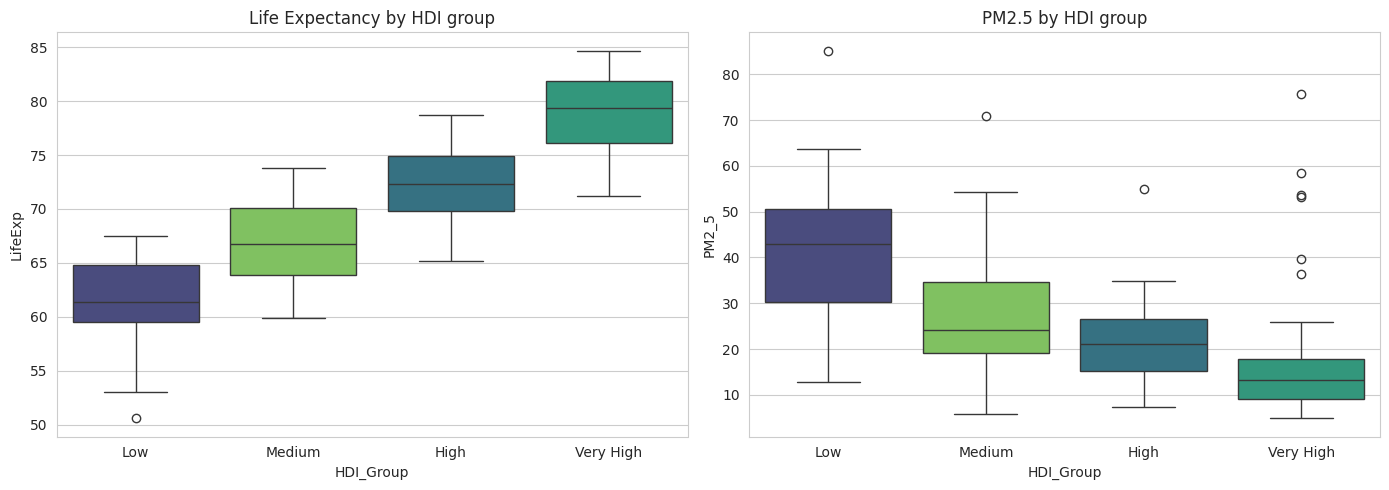

In [ ]:
# TEST 3 - One-way ANOVA across HDI groups

# H0: mean(Low) = mean(Medium) = mean(High) = mean(Very High)
# H1: at least one HDI-group mean differs
# Tested separately for Life Expectancy and for PM2.5.

print("TEST 3 - One-way ANOVA across the four HDI groups")
print()
print("H0: all four HDI-group means are equal")
print("H1: at least one mean differs\n")

for col in ["LifeExp", "PM2_5"]:
    groups = [df[df["HDI_Group"] == g][col].values for g in group_order]
    F, p = stats.f_oneway(*groups)
    print(f"  {col:<8}  F = {F:8.3f}   p = {p:.3e}   --> {verdict(p)}")


print()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x="HDI_Group", y="LifeExp",
            order=group_order, palette="viridis", ax=axes[0], hue="HDI_Group", legend=False)
axes[0].set_title("Life Expectancy by HDI group")
sns.boxplot(data=df, x="HDI_Group", y="PM2_5",
            order=group_order, palette="viridis", ax=axes[1], hue="HDI_Group", legend=False)
axes[1].set_title("PM2.5 by HDI group")
plt.tight_layout(); plt.show()


In [ ]:
# TEST 4 - Pairwise Student's t-tests across HDI groups

# Follow-up to the ANOVA: which HDI-group pairs actually differ?
# H0: mean(group A) = mean(group B)
# H1: mean(group A) != mean(group B)


print("TEST 4 - Pairwise Student's t-tests across HDI groups")
print()
print("H0: the two HDI-group means are equal")
print("H1: they differ\n")

from itertools import combinations
pair_list = list(combinations(group_order, 2))

for col in ["LifeExp", "PM2_5"]:
    print(f"--- {col} ---")
    rows = []
    for g1, g2 in pair_list:
        a = df[df["HDI_Group"] == g1][col]
        b = df[df["HDI_Group"] == g2][col]
        t, p = stats.ttest_ind(a, b, equal_var=True)   # Student's t
        rows.append({"group_A": g1, "group_B": g2,
                     "n_A": len(a), "n_B": len(b),
                     "t": t, "p": p,
                     "decision": verdict(p)})
    print(pd.DataFrame(rows).to_string(index=False, float_format=lambda v: f"{v:.4g}"))
    print()

TEST 4 - Pairwise Student's t-tests across HDI groups

H0: the two HDI-group means are equal
H1: they differ

--- LifeExp ---
group_A   group_B  n_A  n_B      t         p  decision
    Low    Medium   27   47 -5.922 9.959e-08 REJECT H0
    Low      High   27   50 -12.34  9.98e-20 REJECT H0
    Low Very High   27   66 -20.05 3.785e-35 REJECT H0
 Medium      High   47   50  -7.24 1.159e-10 REJECT H0
 Medium Very High   47   66 -16.72 4.277e-32 REJECT H0
   High Very High   50   66 -9.845  6.39e-17 REJECT H0

--- PM2_5 ---
group_A   group_B  n_A  n_B     t         p  decision
    Low    Medium   27   47 4.123 9.898e-05 REJECT H0
    Low      High   27   50 7.234  3.37e-10 REJECT H0
    Low Very High   27   66 7.866 7.235e-12 REJECT H0
 Medium      High   47   50 2.442   0.01646 REJECT H0
 Medium Very High   47   66  4.24 4.648e-05 REJECT H0
   High Very High   50   66 2.459   0.01543 REJECT H0



In [ ]:
# TEST 5 - Pairwise two-sample z-tests across HDI groups

# Same hypotheses as Test 4 but the test statistic is compared
# against the standard normal distribution instead of t.
# H0: mean(group A) = mean(group B)
# z = (mean_A - mean_B) / sqrt(var_A/n_A + var_B/n_B)


print("TEST 5 - Pairwise two-sample z-tests across HDI groups")
print()
print("H0: the two HDI-group means are equal")
print("H1: they differ\n")

for col in ["LifeExp", "PM2_5"]:
    print(f"--- {col} ---")
    rows = []
    for g1, g2 in pair_list:
        a = df[df["HDI_Group"] == g1][col]
        b = df[df["HDI_Group"] == g2][col]
        z, p = two_sample_z_test(a, b)
        rows.append({"group_A": g1, "group_B": g2,
                     "n_A": len(a), "n_B": len(b),
                     "z": z, "p": p,
                     "decision": verdict(p)})
    print(pd.DataFrame(rows).to_string(index=False, float_format=lambda v: f"{v:.4g}"))
    print()

TEST 5 - Pairwise two-sample z-tests across HDI groups

H0: the two HDI-group means are equal
H1: they differ

--- LifeExp ---
group_A   group_B  n_A  n_B      z         p  decision
    Low    Medium   27   47  -5.71 1.132e-08 REJECT H0
    Low      High   27   50 -11.43         0 REJECT H0
    Low Very High   27   66 -18.44         0 REJECT H0
 Medium      High   47   50 -7.213 5.487e-13 REJECT H0
 Medium Very High   47   66 -16.54         0 REJECT H0
   High Very High   50   66 -9.924         0 REJECT H0

--- PM2_5 ---
group_A   group_B  n_A  n_B     z         p  decision
    Low    Medium   27   47 3.953 7.707e-05 REJECT H0
    Low      High   27   50 6.092 1.114e-09 REJECT H0
    Low Very High   27   66 7.289 3.113e-13 REJECT H0
 Medium      High   47   50 2.408   0.01604 REJECT H0
 Medium Very High   47   66  4.22 2.438e-05 REJECT H0
   High Very High   50   66 2.609  0.009089 REJECT H0



In [38]:
# TEST 6 - One-way ANOVA across world regions

# H0: mean of the variable is equal across all OWID regions
# H1: at least one regional mean differs

print("TEST 6 - One-way ANOVA across world regions")
print()
print("H0: regional means are equal")
print("H1: at least one region differs\n")

regions = [r for r in df["Region"].unique()
           if len(df[df["Region"] == r]) >= 2]

for col in ["PM2_5", "LifeExp", "HDI"]:
    groups = [df[df["Region"] == r][col].values for r in regions]
    F, p = stats.f_oneway(*groups)
    print(f"  {col:<8}  F = {F:8.3f}   p = {p:.3e}   --> {verdict(p)}")

TEST 6 - One-way ANOVA across world regions

H0: regional means are equal
H1: at least one region differs

  PM2_5     F =   25.817   p = 1.061e-19   --> REJECT H0
  LifeExp   F =   44.887   p = 3.858e-30   --> REJECT H0
  HDI       F =   50.230   p = 1.220e-32   --> REJECT H0


TEST 7 - Sensitivity analysis (Gulf countries excluded)

Removed 6 Gulf countries (190 -> 184)

Overall PM2.5 vs LifeExp (Pearson):
  with Gulf     r = -0.4789   p = 2.771e-12   --> REJECT H0
  without Gulf  r = -0.5966   p = 4.045e-19   --> REJECT H0

Within 'Very High HDI' group only (Pearson):
  with Gulf     n= 66   r = -0.1171   p = 0.3491   --> FAIL to reject H0
  without Gulf  n= 60   r = -0.3627   p = 0.0044   --> REJECT H0



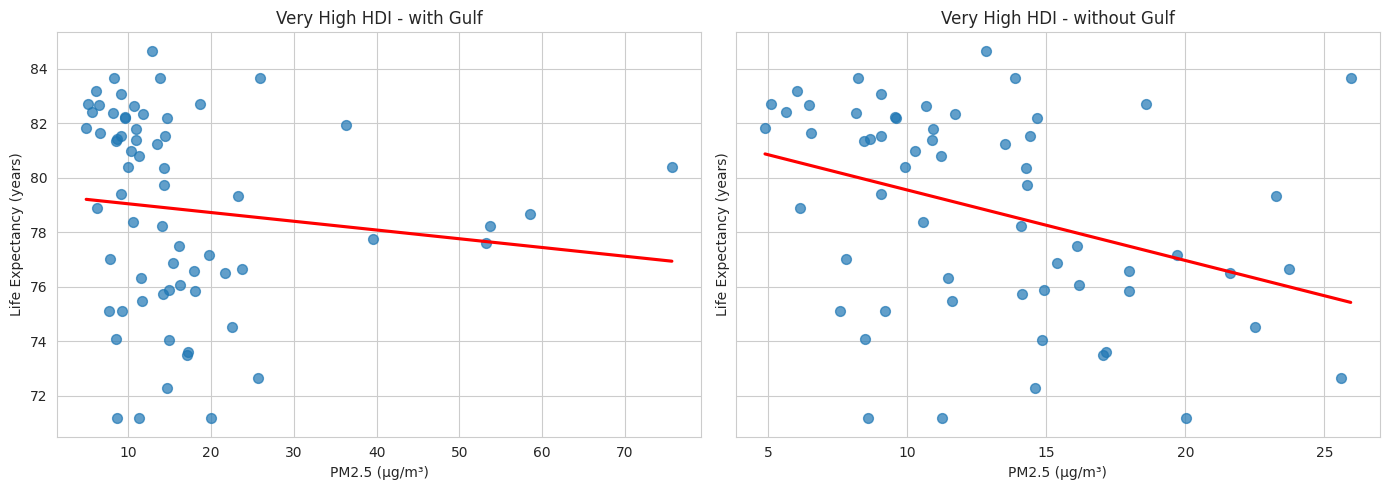

In [ ]:
# TEST 7 - Sensitivity analysis: re-run main correlation with Gulf states excluded

# H0: PM2.5 and LifeExp are uncorrelated (Gulf states excluded)
# H1: they are correlated

print("TEST 7 - Sensitivity analysis (Gulf countries excluded)")
print()

gulf_codes = ["QAT", "BHR", "KWT", "ARE", "SAU", "OMN"]
df_ng = df[~df["Code"].isin(gulf_codes)].copy()
print(f"Removed {len(df) - len(df_ng)} Gulf countries "
      f"({len(df)} -> {len(df_ng)})\n")

print("Overall PM2.5 vs LifeExp (Pearson):")
for label, data in [("with Gulf   ", df), ("without Gulf", df_ng)]:
    r, p = stats.pearsonr(data["PM2_5"], data["LifeExp"])
    print(f"  {label}  r = {r:+.4f}   p = {p:.3e}   --> {verdict(p)}")

print("\nWithin 'Very High HDI' group only (Pearson):")
for label, data in [("with Gulf   ", df), ("without Gulf", df_ng)]:
    sub = data[data["HDI_Group"] == "Very High"]
    r, p = stats.pearsonr(sub["PM2_5"], sub["LifeExp"])
    print(f"  {label}  n={len(sub):>3}   r = {r:+.4f}   p = {p:.4f}   --> {verdict(p)}")

print()
# Side-by-side scatter for the Very High HDI group
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, data, title in [
    (axes[0], df[df["HDI_Group"]=="Very High"],
              "Very High HDI - with Gulf"),
    (axes[1], df_ng[df_ng["HDI_Group"]=="Very High"],
              "Very High HDI - without Gulf"),
]:
    sns.regplot(data=data, x="PM2_5", y="LifeExp", ax=ax, ci=None,
                scatter_kws={"alpha": 0.7, "s": 50},
                line_kws={"color": "red"})
    ax.set_title(title)
    ax.set_xlabel("PM2.5 (µg/m³)"); ax.set_ylabel("Life Expectancy (years)")
plt.tight_layout(); plt.show()

In [ ]:
# Summary table of every test
print("SUMMARY OF ALL HYPOTHESIS TESTS  (alpha = 0.05)")
print()

summary = [
    ("Pearson  PM2.5 vs LifeExp",       stats.pearsonr(df["PM2_5"], df["LifeExp"])[1]),
    ("Pearson  HDI   vs LifeExp",       stats.pearsonr(df["HDI"],   df["LifeExp"])[1]),
    ("Pearson  PM2.5 vs HDI",           stats.pearsonr(df["PM2_5"], df["HDI"])[1]),
    ("Spearman PM2.5 vs LifeExp",       stats.spearmanr(df["PM2_5"], df["LifeExp"])[1]),
    ("Spearman HDI   vs LifeExp",       stats.spearmanr(df["HDI"],   df["LifeExp"])[1]),
    ("Spearman PM2.5 vs HDI",           stats.spearmanr(df["PM2_5"], df["HDI"])[1]),
    ("ANOVA    LifeExp ~ HDI groups",   stats.f_oneway(*[df[df["HDI_Group"]==g]["LifeExp"] for g in group_order])[1]),
    ("ANOVA    PM2.5   ~ HDI groups",   stats.f_oneway(*[df[df["HDI_Group"]==g]["PM2_5"]   for g in group_order])[1]),
    ("ANOVA    PM2.5   ~ Region",       stats.f_oneway(*[df[df["Region"]==r]["PM2_5"]      for r in regions])[1]),
    ("ANOVA    LifeExp ~ Region",       stats.f_oneway(*[df[df["Region"]==r]["LifeExp"]    for r in regions])[1]),
    ("Pearson  PM2.5 vs LifeExp (no Gulf)",
                                        stats.pearsonr(df_ng["PM2_5"], df_ng["LifeExp"])[1]),
    ("Pearson  PM2.5 vs LifeExp | VeryHigh, with Gulf",
                                        stats.pearsonr(df[df["HDI_Group"]=="Very High"]["PM2_5"],
                                                       df[df["HDI_Group"]=="Very High"]["LifeExp"])[1]),
    ("Pearson  PM2.5 vs LifeExp | VeryHigh, no Gulf",
                                        stats.pearsonr(df_ng[df_ng["HDI_Group"]=="Very High"]["PM2_5"],
                                                       df_ng[df_ng["HDI_Group"]=="Very High"]["LifeExp"])[1]),
]

summary_df = pd.DataFrame(summary, columns=["Test", "p-value"])
summary_df["decision"] = summary_df["p-value"].apply(lambda p: verdict(p))
summary_df["p-value"]  = summary_df["p-value"].apply(lambda p: f"{p:.3e}")
print(summary_df.to_string(index=False))

SUMMARY OF ALL HYPOTHESIS TESTS  (alpha = 0.05)

                                           Test   p-value          decision
                      Pearson  PM2.5 vs LifeExp 2.771e-12         REJECT H0
                      Pearson  HDI   vs LifeExp 1.278e-71         REJECT H0
                          Pearson  PM2.5 vs HDI 1.713e-17         REJECT H0
                      Spearman PM2.5 vs LifeExp 7.204e-15         REJECT H0
                      Spearman HDI   vs LifeExp 5.148e-76         REJECT H0
                          Spearman PM2.5 vs HDI 1.106e-21         REJECT H0
                  ANOVA    LifeExp ~ HDI groups 3.704e-54         REJECT H0
                  ANOVA    PM2.5   ~ HDI groups 1.733e-14         REJECT H0
                      ANOVA    PM2.5   ~ Region 1.061e-19         REJECT H0
                      ANOVA    LifeExp ~ Region 3.858e-30         REJECT H0
            Pearson  PM2.5 vs LifeExp (no Gulf) 4.045e-19         REJECT H0
Pearson  PM2.5 vs LifeExp | VeryHigh, w